In [ ]:
# 29/05/26
import os                                     
import tensorflow as tf
from tensorflow.keras import layers, models                                  # type: ignore 
from tensorflow.keras.layers import Dropout                                  # type: ignore 
from tensorflow.keras.preprocessing.image import ImageDataGenerator          # type: ignore 

# For Model 3 onwards 
from tensorflow.keras.callbacks import EarlyStopping                         # type: ignore

# For Model 4
from tensorflow.keras.callbacks import ReduceLROnPlateau                     # type: ignore
from tensorflow.keras.layers import BatchNormalization                       # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint                       # type: ignore
import matplotlib.pyplot as plt


In [2]:
# SECTION 1 — TRAIN DATA AUGMENTATION : “image transformation machine” ----->  image processing pipeline ban rahi hai. (Optimized for pre-augmented data)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,             # 30 se kam karke 20 kiya (kyunki Augmentor ne pehle hi rotate kiya hai)
    zoom_range=0.1,                # 0.2 se kam karke 0.1 kiya taaki patta frame se bahar na nikal jaye
    horizontal_flip=True,          # Isko True rakho, ye hamesha sahi rehta hai
    vertical_flip=False,           # Isko False kar do (khet me patti aamtaur par ulti nahi lٹakti)
    width_shift_range=0.1,         # Shifting thodi kam ki
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],   # Lighting variations ko natural kiya (zyada extreme nahi)
    fill_mode='nearest'
)

# SECTION 2 - Validation data no augmentation (Same rahega)
val_datagen = ImageDataGenerator(rescale=1./255)

In [3]:
# SECTION 3: TRAIN GENERATOR
train_generator = train_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/01_train',
    target_size=(224,224),
    batch_size= 32,
    class_mode='categorical',
    shuffle=True
)

# SECTION 4: VALIDATION GENERATOR
val_generator = val_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/02_validate',
    target_size=(224,224),
    batch_size= 32,
    class_mode='categorical',
    shuffle=True
)


Found 5271 images belonging to 4 classes.
Found 1122 images belonging to 4 classes.


In [4]:
model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 4
model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Block 5 (Naya Heavy Block)
model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

# Global Feature Aggregation (Outputs a 512-d vector now)
model.add(layers.GlobalAveragePooling2D())

# Single, Strong Dense Layer
model.add(layers.Dense(256, activation='relu')) #  Tip: 512 se direct output compress karne ke liye isey 256 rakho, overfit rokesga
model.add(Dropout(0.38))                        #  Hard regularizer for real-world images

# Output Layer
model.add(layers.Dense(4, activation='softmax'))

c:\Users\sanch\Documents\Git_hub\Streamlit-KrishiNetra\krishi_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,900 (6.50 MB)

 Trainable params: 1,702,916 (6.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [6]:
# Compile Model

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])


# 1. Balanced Callbacks (Patience adjusted for heavy real-world data)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience= 5,                  # Badha kar 5 kiya taaki real-world patterns seekhne ka poora mauka mile
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor = 0.2,                  # Sharp reduction for local minima escape
    patience = 3,                  # Wait for 3 epochs before dropping LR
    verbose = 1
)

checkpoint = ModelCheckpoint(
    '../04_models/model_apple_21.1.6.keras', 
    monitor = 'val_loss',
    save_best_only = True,
    verbose = 1
)

# 2. TRAINING (Removed class_weight parameter as dataset is now balanced at ~2k each)
print("\n Training started on Balanced Real-World Dataset ........")
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 26,                   # 26 Epochs perfectly locked
    callbacks=[early_stop, lr_scheduler, checkpoint] 
)


 Training started on Balanced Real-World Dataset ........
Epoch 1/26
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.6339 - loss: 1.0751
Epoch 1: val_loss improved from None to 4.21994, saving model to ../04_models/model_apple_21.1.6.keras

Epoch 1: finished saving model to ../04_models/model_apple_21.1.6.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 157s 934ms/step - accuracy: 0.7194 - loss: 0.7927 - val_accuracy: 0.2594 - val_loss: 4.2199 - learning_rate: 0.0010
Epoch 2/26
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.8372 - loss: 0.4452
Epoch 2: val_loss improved from 4.21994 to 3.83831, saving model to ../04_models/model_apple_21.1.6.keras

Epoch 2: finished saving model to ../04_models/model_apple_21.1.6.keras
165/165 ━━━━━━━━━━━━━━━━━━━━ 151s 913ms/step - accuracy: 0.8570 - loss: 0.4050 - val_accuracy: 0.4171 - val_loss: 3.8383 - learning_rate: 0.0010
Epoch 3/26
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.8988 - loss: 0.2800
Epoch 3: val_loss improved from 

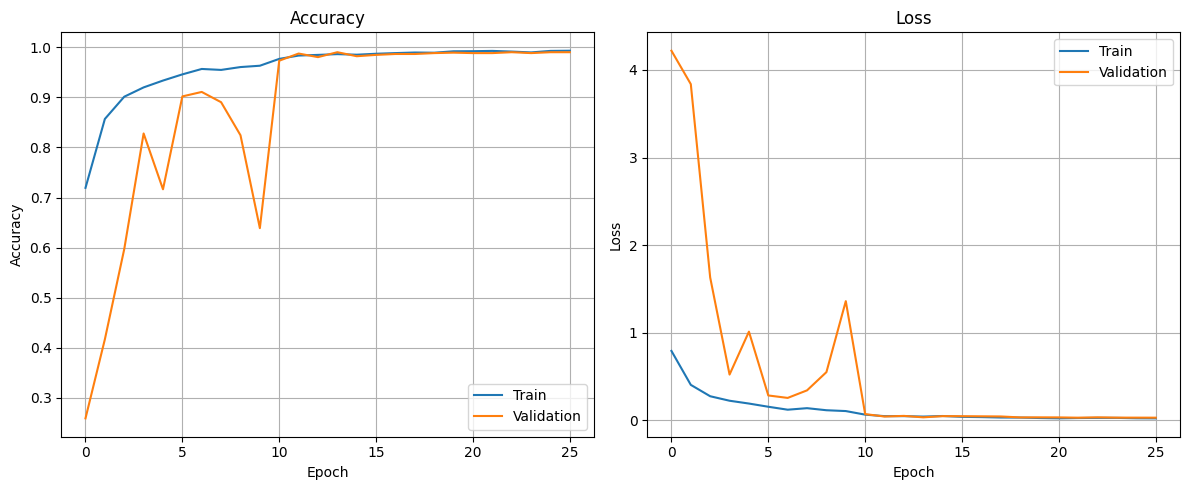

In [7]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# SECTION 5: TEST GENERATOR (For evaluation)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/02_dataset/03_test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # CRITICAL: Isko False hi rakhna hai evaluation ke liye
)

Found 1121 images belonging to 4 classes.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating model on test dataset...")

# 1. Test images par predictions nikalna
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

Evaluating model on test dataset...
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step


In [10]:
# 2. True (Original) labels nikalna
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [11]:
#  SECTION A: OVERALL TEST ACCURACY :Pura dataset par overall evaluation
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print("\n" + "="*50)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")
print("="*50 + "\n")


Final Test Accuracy: 99.02%
Final Test Loss:     0.0238



In [12]:
# --- SECTION B: PRECISION, RECALL, F1-SCORE ---
print("Classification Report (Class-wise Performance):")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Classification Report (Class-wise Performance):
                          precision    recall  f1-score   support

      Apple___Apple_scab       0.99      0.98      0.99       278
       Apple___Black_rot       0.99      0.99      0.99       292
Apple___Cedar_apple_rust       0.99      0.99      0.99       269
         Apple___healthy       0.99      1.00      1.00       282

                accuracy                           0.99      1121
               macro avg       0.99      0.99      0.99      1121
            weighted avg       0.99      0.99      0.99      1121



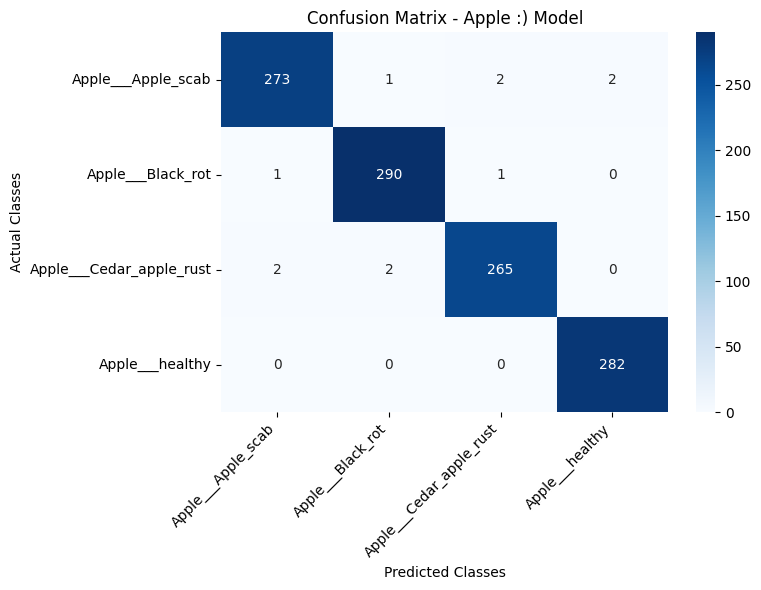

In [13]:
# --- SECTION C: CONFUSION MATRIX ---
# Isse pata chalega kaun sa plant disease kis dusre disease ke sath confuse ho raha hai
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Apple :) Model')
plt.ylabel('Actual Classes')
plt.xlabel('Predicted Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()